In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from tqdm import tqdm
import matplotlib.animation as animation

import scienceplots
plt.style.use(['science', 'grid'])

from PIL import Image
from scipy import ndimage as ndi
from skimage.measure import label, regionprops
from pathlib import Path

from TherMIFASOL.core.variables.GlobalVariables import (
    T_SOLIDUS, T_LIQUIDUS, FAC
)
from TherMIFASOL.core.data_processing.CRED_functions import (
    dl_to_thermo
)
from TherMIFASOL.core.models.ThermalAnalysis import (
    format_storing_shape_dimension, shape_quantification, get_shape_quantification_from_rapport
)
from TherMIFASOL.core.utils.glob import (
    create_unique_folder
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [2]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


# Path to data
#-------------------
data_path = os.path.join(
    PATH_DATA, "experiences/5 FirstEulerienMonitoring/"
)



# Calibration tables
#-------------------

#   CRED:
array_nuc = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp550_WithNeutralDensity.npy"
        )
    )
array_calibration = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/FLUX/FLUX_IT40_deg1_NUC2.npy"
        )
    )


# Saving path
#------------
saving_path = os.path.join(BASE_DIR, "results/FirstEulerienMonitoring/")

## design of experiments
On the cell, only a single set of parameters currently enables stable processing. Therefore, in this experimental plan, we propose to make only minimal adjustments to the main process parameters (wire feed rate and laser power) and instead rely on alternative levers to induce variations in the melt pool behavior.

The investigated levers are:

* Unidirectional vs. bidirectional strategy
* With or without active cooling
* Camera field of view positioned near the melt pool or higher along the wall
* With or without laser power regulation via the Emaq-s camera
* Short vs. long delay time

| Strategy        | Active cooling | Position camera | Emaq-s | Delay | Folder name  |
|------------------|------------------------|-----------------|--------|---------------|-------|
| Unidirectional | yes                   | High            | No    | Short        |  RA  |
| Unidirectional | no                   | High            | No    | Short        |  SANS_GAZ  |
| Unidirectional | No                   | Low             | No    | Short        |  LOW_POS(_BIS) |
| Unidirectional | No                   | High            | Yes    | Short        |  EMAQS  |
| Bidirectional | No                   | High            | Yes    | Short        |  BIDIREC  |
| Unidirectional | No                   | High            | Yes    | Long        | TEMPOR_LONGUE |


In [3]:
configuration: str = 'TEMPOR_LONGUE'
layer_id: int = 25
emissivity_value = 0.73

pyrometer_pos_X, pyrometer_pos_Y = 600, 313
start_frame, end_frame = 0, 850
frame_every = 2

### Folder initialization

In [4]:
save_dir = create_unique_folder(
    path=os.path.join(saving_path, f"shape analysis/{configuration}/")
)

os.mkdir(f'{save_dir}/success')
os.mkdir(f'{save_dir}/failure')

## Camera

### Collect data

In [5]:
# Cannot cast ufunc 'add' output from dtype('float64') to dtype('uint16') with casting rule 'same_kind'
# The data type of the table may cause problems.

data_cordon= []

for im in np.arange(start_frame, end_frame, frame_every):
    raw_image = np.load(
        f"{data_path}/{configuration}/cam_{configuration}_c{layer_id}/data/im_{im}.npy"
        ).astype(np.float64)
    thermal_array = dl_to_thermo(
        dl_raw=raw_image,
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=emissivity_value
    )
    data_cordon.append(thermal_array)
    
data_cordon = np.asarray(data_cordon)
nb_img_sub = data_cordon.shape[0]

### Ellipse approximation

In [6]:
def my_ellipse(abx, a, b, xc, yc):
    return b*np.sqrt(1 - ((abx - xc)/a)**2) + yc

In [7]:
report_path = os.path.join(save_dir, "rapport.txt")

with open(report_path, "w") as rapport:
    # --- Header ---
    rapport.write(time.ctime() + '\n')
    rapport.write(f"{configuration}\ncordon : {layer_id}\n")
    rapport.write(f"id img start : {start_frame} - id img end : {end_frame} - step {frame_every} img\n\n")
    rapport.write(f"epsilon : {emissivity_value}\nEllipse center : ({pyrometer_pos_X}, {pyrometer_pos_Y})\n")
    rapport.write(f"scale factor : {FAC} [px/mm]\n")
    rapport.write(f"Solidus : {T_SOLIDUS} K\nLiquidus : {T_LIQUIDUS} K\n\n")
    rapport.write(f"{'Index':^10} | {'length liquidus':^20} | {'depth liquidus':^20} | "
                  f"{'length solidus':^20} | {'depth solidus':^20}\n")
    rapport.write("-" * 100 + "\n")

    # --- Init figure (created once) ---
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    circ = Circle((pyrometer_pos_X, pyrometer_pos_Y), 5, color="r", zorder=10)
    ax.add_patch(circ)
    im = ax.imshow(np.zeros_like(data_cordon[0]), interpolation="nearest",
                   vmin=1000, vmax=1600, cmap="gray")
    # scatter_liq = ax.scatter([], [], c="blue", s=1, label="Liquidus")
    scatter_sol = ax.scatter([], [], c="green", s=1, label="Solidus")
    # line_liq, = ax.plot([], [], "--", c="blue", lw=1, label="ellipse approximation (liq)")
    line_sol, = ax.plot([], [], "--", c="green", lw=1, label="ellipse approximation (sol)")
    cbar = fig.colorbar(im, ax=ax, orientation="vertical")
    cbar.ax.axhline(T_SOLIDUS-273.15, color='green', linewidth=2)
    cbar.set_label('Température [°C]', fontsize=12)

    ax.set_xlim(0, 640)
    ylabels = [str(i * FAC) for i in np.arange(0, 512, 100)]
    plt.yticks(np.arange(0, 512, 100), ylabels)
    xlabels = [str(i * FAC) for i in np.arange(0, 640, 100)]
    plt.xticks(np.arange(0, 640, 100), xlabels)
    plt.legend(ncol=2)
    plt.tight_layout()

    # --- Loop over images ---
    SUCCESS, FAILURE = 0, 0

    for id_img, work_im in enumerate(
        tqdm(data_cordon, total=nb_img_sub, desc="Processing images")
        ):

        mask_mushy = (work_im > T_SOLIDUS) & (work_im < T_LIQUIDUS)
        mask_solidus = (work_im > T_SOLIDUS - 5) & (work_im < T_SOLIDUS + 5)
        mask_liquidus = (work_im > T_LIQUIDUS - 5) & (work_im < T_LIQUIDUS + 5)

        pos_ = (np.argmax(mask_mushy == 1) % 640,
                np.argmax(mask_mushy == 1) // 640)
        depth_concerned = 512 - np.argmax(mask_mushy == 1) // 640

        area_detected_as_mushy = np.sum(mask_mushy)
        tot_area = 640 * depth_concerned

        if area_detected_as_mushy > tot_area * 0.02:
            mushy = np.zeros_like(work_im)
            mushy_label = label(mask_mushy)
            rps = np.asarray(regionprops(mushy_label))
            areas = np.asarray([r.area for r in rps])
            idxs = np.argsort(areas)[::-1]

            flag_ind = np.argmax(areas[idxs] / areas[idxs[0]] > 0.25)

            for idx in idxs[:flag_ind + 1]:
                mushy[tuple(rps[idx].coords.T)] = 1
            mushy = ndi.binary_fill_holes(mushy == 1)

            y_liq, x_liq = np.where(mushy & mask_liquidus)
            y_sol, x_sol = np.where(mushy & mask_solidus)
            y_liq, x_liq = y_liq[x_liq < pyrometer_pos_X], x_liq[x_liq < pyrometer_pos_X]
            y_sol, x_sol = y_sol[x_sol < pyrometer_pos_X], x_sol[x_sol < pyrometer_pos_X]

            # Ellipse fitting
            a_liq, b_liq = shape_quantification(
                x_pts=x_liq, 
                y_pts=y_liq, 
                xc=pyrometer_pos_X, 
                yc=pyrometer_pos_Y
            )
            a_sol, b_sol = shape_quantification(
                x_pts=x_sol, 
                y_pts=y_sol, 
                xc=pyrometer_pos_X, 
                yc=pyrometer_pos_Y
            )
            # Turn 'px' into 'mm'
            a_mm_liq, b_mm_liq = np.round(FAC * a_liq, 1), np.round(FAC * b_liq, 1)
            a_mm_sol, b_mm_sol = np.round(FAC * a_sol, 1), np.round(FAC * b_sol, 1)

            pb = np.sum(np.isnan([a_sol, b_sol])) > 0
            if pb:
                FAILURE += 1
                path_stor_img = os.path.join(save_dir, f"failure/im_{id_img}.png")
            else:
                SUCCESS += 1
                true_id = id_img * frame_every + start_frame
                path_stor_img = os.path.join(save_dir, f"success/im_{true_id}.png")
                line = format_storing_shape_dimension(
                    index=true_id, 
                    value1=a_liq, 
                    value2=b_liq, 
                    value3=a_sol, 
                    value4=b_sol
                )
                rapport.write(line)

            # --- Update plot ---
            im.set_data(work_im)
            # scatter_liq.set_offsets(np.c_[x_liq, y_liq])
            scatter_sol.set_offsets(np.c_[x_sol, y_sol])

            if not pb:
                x_ellipse_liq = np.arange(pyrometer_pos_X - a_liq, pyrometer_pos_X, 1)
                y_ellipse_liq = my_ellipse(x_ellipse_liq, a_liq, b_liq, pyrometer_pos_X, pyrometer_pos_Y)
                x_ellipse_sol = np.arange(pyrometer_pos_X - a_sol, pyrometer_pos_X, 1)
                y_ellipse_sol = my_ellipse(x_ellipse_sol, a_sol, b_sol, pyrometer_pos_X, pyrometer_pos_Y)
                # line_liq.set_data(x_ellipse_liq, y_ellipse_liq)
                line_sol.set_data(x_ellipse_sol, y_ellipse_sol)
            else:
                # line_liq.set_data([], [])
                line_sol.set_data([], [])

            fig.savefig(path_stor_img, dpi=150)

        else:
            print(f"Small area [%] : {100 * area_detected_as_mushy / (tot_area * 0.02):.1f}")

    rapport.write(f"\n\nFailure : {int(100 * FAILURE / nb_img_sub)}%\n")
    rapport.write(f"Success : {int(100 * SUCCESS / nb_img_sub)}%\n")
    rapport.write(f"Not treated : {int(100 * (nb_img_sub - SUCCESS - FAILURE) / nb_img_sub)}%\n")

plt.close(fig)

Processing images: 100%|██████████| 425/425 [01:55<00:00,  3.69it/s]


### Fancy animation

In [8]:
save_dir = os.path.join(saving_path, f"shape analysis/{configuration}/")
# Shape data
rapport = get_shape_quantification_from_rapport(
    path=os.path.join(save_dir, "rapport.txt")
    )
indexes_images = rapport['data'][:,0].astype(int)
length_solidus = rapport['data'][:,3]*FAC
depth_solidus = rapport['data'][:,4]*FAC

# Time management
acquisition_time = np.loadtxt(
    os.path.join(data_path, configuration, f"cam_{configuration}_c{layer_id}", "time.txt")
    )
relative_time = acquisition_time[indexes_images] - acquisition_time[indexes_images][0]
dt = np.mean(np.diff(relative_time))

# Images
images = []
for i in indexes_images:
    image_path = os.path.join(save_dir, f"success/im_{int(i)}.png")
    images.append(np.array(Image.open(image_path)))

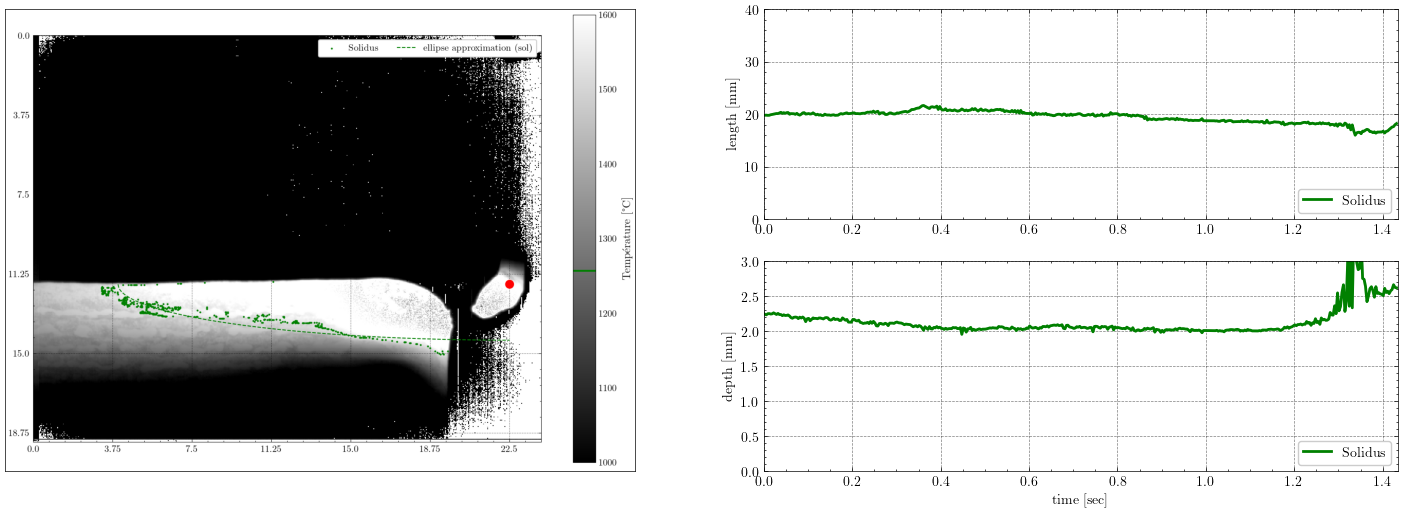

In [12]:
# Configuration de la figure et des axes
fig = plt.figure(figsize=(18, 6))

# Axe pour les images à gauche
ax_image = fig.add_subplot(121)
im = ax_image.imshow(images[0], cmap="gray")
ax_image.set_xticks([])
ax_image.set_yticks([])

# Axes pour les graphiques à droite
ax1 = fig.add_subplot(222)
ax2 = fig.add_subplot(224, sharex=ax1)

# Courbes dynamiques
l_sol, = ax1.plot([], [], lw=2, c='g', label='Solidus')
d_sol, = ax2.plot([], [], lw=2, c='g', label='Solidus')

# Courbes complètes en arrière-plan
ax1.plot(relative_time, length_solidus, lw=2, alpha=0.2, c='g')
ax2.plot(relative_time, depth_solidus, lw=2, alpha=0.2, c='g')

# Mise en forme
ax1.set_xlim(relative_time[0], relative_time[-1])
ax1.set_ylim(0, 40)
ax1.set_ylabel('length [mm]')

ax2.set_xlim(relative_time[0], relative_time[-1])
ax2.set_ylim(0, 3)
ax2.set_ylabel('depth [mm]')
ax2.set_xlabel('time [sec]')

ax1.legend(fontsize=10, loc='lower right')
ax2.legend(fontsize=10, loc='lower right')

def animate(i):
    l_sol.set_data(relative_time[:i], length_solidus[:i])
    d_sol.set_data(relative_time[:i], depth_solidus[:i])
    im.set_array(images[i])
    return im, l_sol, d_sol

ani = animation.FuncAnimation(fig, animate, frames=nb_img_sub, interval=dt, blit=True)
ani.save(os.path.join(save_dir, "shape_evolution.gif"), writer="pillow", fps=1/dt)